### Sandbox for creating model output visualization in the form of a raster heatmap 
- Daily, weekly, monthly aggregates with statistic (count or percentage) of seeds that end up within a grid cell
- This can be done across the entire model domain, as well as just the grid cell closest to shore

In [ ]:
import matplotlib.pyplot as plt
import os
import xarray as xr
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
import cmocean


In [ ]:
### First, let's make sure we can access the model output files.

# Define the directory where model output files are stored
output_dir = "../DailyModelRuns/model_output"
# List all files in the output directory
output_files = os.listdir(output_dir)
# Print the list of files with .nc extension
output_files = [f for f in output_files if f.endswith('.nc')]
print("Model output files:", output_files)


Model output files: ['concave_hrf_20250520T032100_continuous.nc', 'concave_hrf_20250520T134300_continuous.nc', 'concave_hrf_20250517T104000_continuous.nc', 'concave_hrf_20250518T113000_continuous.nc', 'concave_hrf_20250519T123000_continuous.nc', 'concave_hrf_20250521T040000_continuous.nc', 'concave_hrf_20240623T231800_continuous.nc', 'concave_hrf_20250420T033300_continuous.nc', 'concave_hrf_20250420T125700_continuous.nc', 'concave_hrf_20250421T042700_continuous.nc', 'concave_hrf_20250421T141200_continuous.nc', 'concave_hrf_20250422T050500_continuous.nc', 'concave_hrf_20250422T153100_continuous.nc', 'concave_hrf_20250424T060600_continuous.nc', 'concave_hrf_20250424T175300_continuous.nc', 'concave_hrf_20250425T063700_continuous.nc', 'concave_hrf_20250425T185700_continuous.nc', 'concave_hrf_20250426T070800_continuous.nc', 'concave_hrf_20250426T195900_continuous.nc', 'concave_hrf_20250427T074200_continuous.nc', 'concave_hrf_20250427T210000_continuous.nc', 'concave_hrf_20250428T081800_conti

In [ ]:
# look at a single file
ds = xr.open_dataset(os.path.join(output_dir, output_files[0]))

### Build 1km x 1km grid 

In [109]:
def create_grid(ds):

    # 1. Create a grid of 1km x 1km cells over the area of interest

    # Flatten all points across time and space into x/y arrays
    x = ds['lon'].values.ravel()
    y = ds['lat'].values.ravel()

    # Get fill values
    fill_lon = ds['lon']._FillValue if '_FillValue' in ds['lon'].attrs else 9.969209968386869e+36
    fill_lat = ds['lat']._FillValue if '_FillValue' in ds['lat'].attrs else 9.969209968386869e+36

    # Mask invalid values using x and y, not lon/lat
    mask = (
        np.isfinite(x) &
        np.isfinite(y) &
        (x != fill_lon) &
        (y != fill_lat)
    )
    x = x[mask]
    y = y[mask]
    print(f"Kept {x.size} points after filtering")

    # Convert to points GeoSeries
    points = gpd.GeoSeries(gpd.points_from_xy(x, y), crs="EPSG:4326").to_crs("EPSG:32610")  # or your UTM zone

    # Compute bounding box in projected coords
    xmin, ymin, xmax, ymax = points.total_bounds
    cell_size = 1000  # meters
    grid_cells = []

    for x0 in np.arange(xmin, xmax, cell_size):
        for y0 in np.arange(ymin, ymax, cell_size):
            x1 = x0 + cell_size
            y1 = y0 + cell_size
            grid_cells.append(Polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)]))

    grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=points.crs)

    # 2. Count the number of points in each grid cell and compute percentage

    join = gpd.sjoin(gpd.GeoDataFrame(geometry=points), grid, predicate='within')

    # Count how many points per cell
    counts = join['index_right'].value_counts()

    # Add counts to grid and compute percentage
    grid['count'] = grid.index.map(counts).fillna(0)
    grid['pct'] = (grid['count'] / grid['count'].sum()) * 100

    return grid, points


### Plot Heat Map 

In [110]:
grid, points = create_grid(ds)
grid

Kept 51750 points after filtering


,geometry,count,pct
0,"POLYGON ((522325.403 4166830.911, 523325.403 4...",0.0,0.0
1,"POLYGON ((522325.403 4167830.911, 523325.403 4...",0.0,0.0
2,"POLYGON ((522325.403 4168830.911, 523325.403 4...",0.0,0.0
3,"POLYGON ((522325.403 4169830.911, 523325.403 4...",0.0,0.0
4,"POLYGON ((522325.403 4170830.911, 523325.403 4...",0.0,0.0
...,...,...,...
697,"POLYGON ((547325.403 4188830.911, 548325.403 4...",0.0,0.0
698,"POLYGON ((547325.403 4189830.911, 548325.403 4...",0.0,0.0
699,"POLYGON ((547325.403 4190830.911, 548325.403 4...",0.0,0.0
700,"POLYGON ((547325.403 4191830.911, 548325.403 4...",0.0,0.0


In [132]:
def heat_map(grid):
    # Import bathymetry layer for contours 
    ds_o = xr.open_dataset('/home/pdaniel/SurfaceCurrentMaps/DailyModelRuns/data/sf_bay_topo.nc')
    elv = ds_o['band_data'].values
    xx = ds_o.x.values
    yy = ds_o.y.values

    # Plot heatmap

    # Reproject grid back to WGS84 for plotting
    grid_deg = grid.to_crs("EPSG:4326")

    # Create axes with a Cartopy CRS
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # add features
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    # Mask zero values
    grid_deg['pct_masked'] = grid_deg['pct'].mask(grid_deg['pct'] == 0)

    # Plot with masked values (they won’t be drawn)
    grid_deg.plot(
        column='pct_masked',
        ax=ax,
        legend=True,
        cmap='magma_r',
        edgecolor='white',
        zorder=0
    )

    # High-res land
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', '10m',
        edgecolor='face', facecolor='slategrey'
    )
    ax.add_feature(land, zorder=1)

    # High-res coastline
    coastline = cfeature.NaturalEarthFeature(
        'physical', 'coastline', '10m',
        edgecolor='black', facecolor='none', linewidth=0.8
    )
    ax.add_feature(coastline, zorder=2)

    ax.set_xlim(-123.05, -122.35)
    ax.set_ylim(37.5, 38.1)

    # Add bathymetry contours for context
    levels = [0,10,20,50,100,200,500,1000]
    ax.contourf(xx,yy,-1*elv[0],zorder=-2,cmap=cmocean.cm.ice_r,levels=levels)
    cont = ax.contour(xx,yy,-1*elv[0],levels=levels[1:],colors='k',linewidths=0.4,linestyles='solid')
    #ax.clabel(cont, inline=True, fontsize=10, fmt='%1.0f') # Note I removed labels

    plt.title('% of points per grid cell over 1 day of model run')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show();

Kept 51750 points after filtering


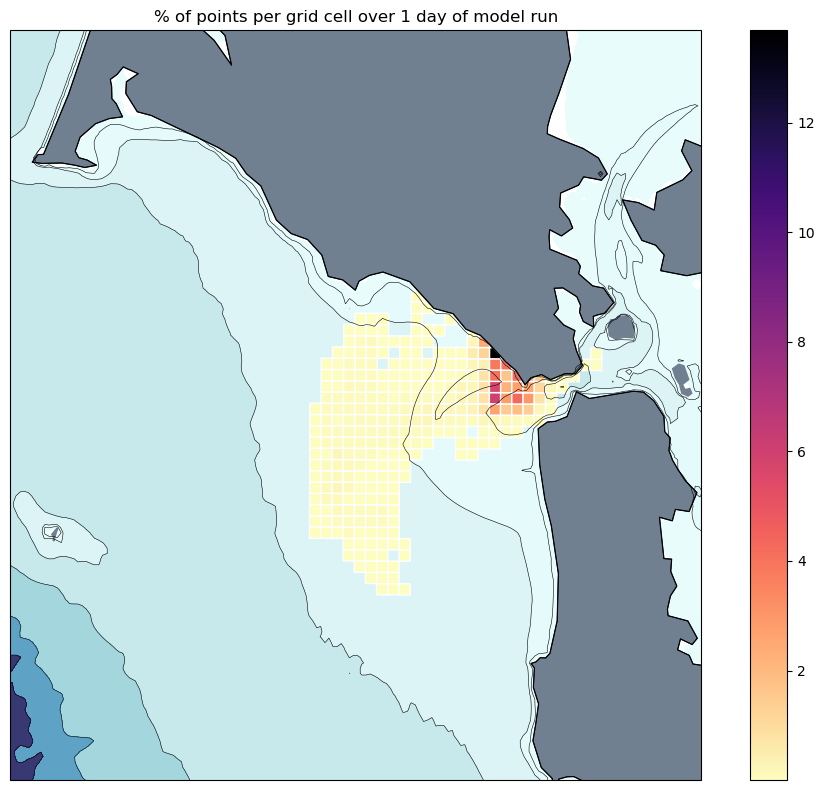

In [136]:
grid, points = create_grid(ds)
heat_map(grid)

#### Currently, the .nc files being generated include a 24 hour model run. Let's concatenate a week of data and then create a heat map from it.


In [134]:
from datetime import datetime, timedelta
# 1️⃣ Compute cutoff date for last 7 days

now = datetime.utcnow()
cutoff = now - timedelta(days=14)

def file_date(fname):
    # extract datetime from filename: concave_hrf_YYYYMMDDTHHMMSS_continuous.nc
    date_str = fname.split('_')[2]  # '20250520T032100'
    return datetime.strptime(date_str, "%Y%m%dT%H%M%S")

recent_files = [os.path.join(output_dir,f) for f in output_files if file_date(f) >= cutoff]
#recent_files = sorted(recent_files, key=file_date)  # sort by time

print(f"Found {len(recent_files)} files in the last 7 days")

# 3️⃣ Open and concatenate into a single xarray dataset
ds_list = [xr.open_dataset(f) for f in recent_files]

ds_concat = xr.concat(ds_list, dim="time")

ds_concat

Found 19 files in the last 7 days


<xarray.Dataset> Size: 141MB
Dimensions:                                                                              (
                                                                                          trajectory: 750,
                                                                                          time: 1843)
Coordinates:
  * trajectory                                                                           (trajectory) int32 3kB ...
  * time                                                                                 (time) datetime64[ns] 15kB ...
    lon                                                                                  (trajectory, time) float32 6MB ...
    lat                                                                                  (trajectory, time) float32 6MB ...
Data variables: (12/24)
    status                                                                               (trajectory, time) int32 6MB ...
    moving                                                                               (trajectory, time) int32 6MB ...
    age_seconds                                                                          (trajectory, time) float32 6MB ...
    origin_marker                                                                        (trajectory, time) int16 3MB ...
    z                                                                                    (trajectory, time) float32 6MB ...
    wind_drift_factor                                                                    (trajectory, time) float32 6MB ...
    ...                                                                                   ...
    surface_downward_x_stress                                                            (trajectory, time) float32 6MB ...
    surface_downward_y_stress                                                            (trajectory, time) float32 6MB ...
    turbulent_kinetic_energy                                                             (trajectory, time) float32 6MB ...
    turbulent_generic_length_scale                                                       (trajectory, time) float32 6MB ...
    sea_floor_depth_below_sea_level                                                      (trajectory, time) float32 6MB ...
    land_binary_mask                                                                     (trajectory, time) float32 6MB ...
Attributes: (12/52)
    Conventions:                                  CF-1.6
    standard_name_vocabulary:                     CF-1.6
    featureType:                                  trajectory
    history:                                      Created 2025-09-05 11:15:51...
    source:                                       Output from simulation with...
    model_url:                                    https://github.com/OpenDrif...
    ...                                           ...
    geospatial_lat_resolution:                    point
    geospatial_lon_min:                           0.0
    geospatial_lon_max:                           0.0
    geospatial_lon_units:                         degrees_east
    geospatial_lon_resolution:                    point
    runtime:                                      0:01:15.539005

Kept 983250 points after filtering


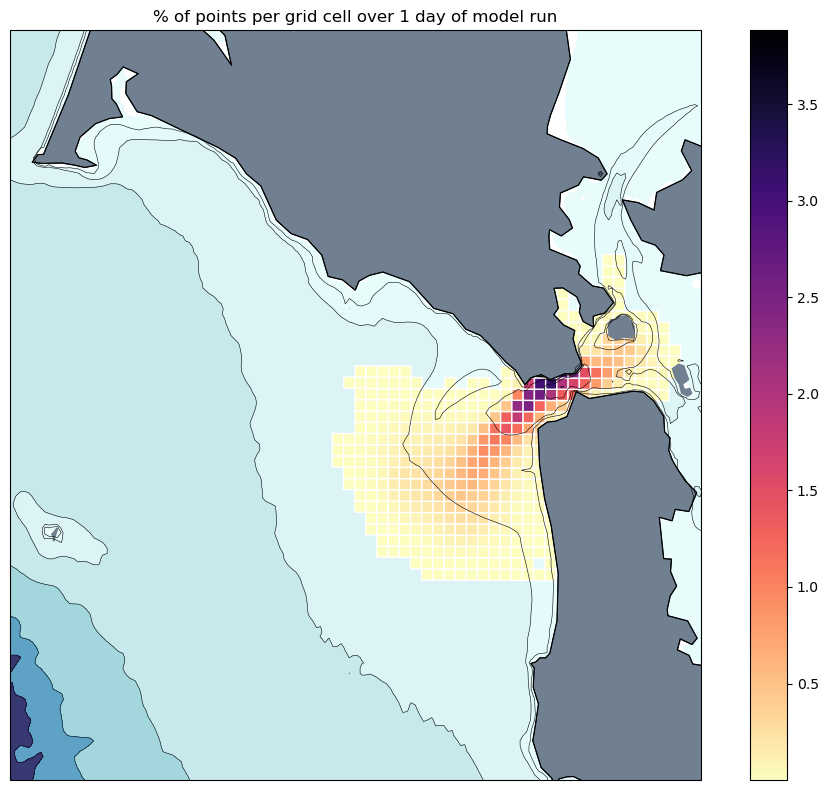

In [135]:
grid, points = create_grid(ds_concat)
heat_map(grid)

In [139]:
#xr.open_dataset('/home/pdaniel/SurfaceCurrentMaps/DailyModelRuns/model_output/netcdf_model_v2/concave_hrf_20250914T140700_continuous.nc')